In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
import numpy as np
import torch
import pprint
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

# add parent dir so importing top level files works in notebook subdir
parent_dir = str(Path().resolve().parent)
sys.path.insert(0, parent_dir)

from llm import qwen_utils, tools
from autoencoder.model_qwen import QwenAutoencoder

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [8]:
if "model" in locals():
    del model # pyright: ignore # noqa
if "processor" in locals():
    del processor # pyright: ignore # noqa
# Load patched Qwen3-VL model with custom feature injection support
model, processor = qwen_utils.get_patched_qwen3(size="32B", use_fp8=False)
print(f"Model loaded on device: {model.device}")

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

model-00004-of-00014.safetensors:   0%|          | 0.00/4.88G [00:00<?, ?B/s]

model-00002-of-00014.safetensors:   0%|          | 0.00/4.88G [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

Model loaded on device: cuda:0


In [3]:
graph_dir = Path("output/qwen3_da3_highdim_latent/video18_00979/graph")
preprocessed_dir = Path("data/preprocessed/qwen3_da3_subsampled/video18_00979")
ae_path = Path("data/preprocessed/qwen3_da3_subsampled/video18_00979/autoencoder/best_ckpt.pth")

print(f"Graph dir: {graph_dir}")
print(f"Autoencoder path: {ae_path}")

Graph dir: output/qwen3_da3_highdim_latent/video18_00979/graph
Autoencoder path: data/preprocessed/qwen3_da3_subsampled/video18_00979/autoencoder/best_ckpt.pth


In [4]:
# Load autoencoder
autoencoder = QwenAutoencoder(input_dim=20480, latent_dim=16).to("cuda")
autoencoder.load_state_dict(torch.load(ae_path, map_location="cuda"))
autoencoder.eval()
print(f"Autoencoder loaded from {ae_path}")

# Load graph data and create toolkit (accepts npz directly)
toolkit = tools.GraphTools(
    positions=np.load(graph_dir / "positions.npy"),
    clusters=np.load(graph_dir / "clusters.npy"),
    centroids=np.load(graph_dir / "c_centroids.npy"),
    centers=np.load(graph_dir / "c_centers.npy"),
    extents=np.load(graph_dir / "c_extents.npy"),
    adjacency=np.load(graph_dir / "graph.npy"),
    bhattacharyya_coeffs=np.load(graph_dir / "bhattacharyya_coeffs.npy"),
    qwen_feats=np.load(graph_dir / "c_qwen_feats.npz"),
    patch_latents_through_time=np.load(graph_dir / "patch_latents_through_time.npy"),
    autoencoder=autoencoder,
)
graph_tools = toolkit.get_all_tools()
print(f"Loaded {len(graph_tools)} tools: {list(graph_tools.keys())}")
print(f"Graph has {len(np.unique(toolkit.clusters))} nodes, {toolkit.adjacency.shape[0]} timesteps")

Autoencoder loaded from data/preprocessed/qwen3_da3_subsampled/video18_00979/autoencoder/best_ckpt.pth
Loaded 9 tools: ['node_distances_through_time', 'node_overlap_scores_through_time', 'node_overlap_position_at_time', 'inspect_highres_node_at_time', 'inspect_node_through_time', 'inspect_scene_at_time', 'voxelize_scene', 'node_movement', 'relative_movement']
Graph has 11 nodes, 20 timesteps


Patch features shape: (294, 20480)
Patch map shape: (1, 448, 672)
Instance mask shape: (448, 672)
Image shape: (448, 672, 3)

Instance IDs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24]
Number of instances (including background): 25

Patch grid: 14x21, factor: 32

Patch grouping by instance:
  background: 0 patches (indices: [])
  instance 1: 26 patches (indices: [0 1 2 3 4]...)
  instance 2: 20 patches (indices: [63 64 84 85 86]...)
  instance 3: 33 patches (indices: [15 16 17 18 19]...)
  instance 4: 7 patches (indices: [70 71 90 91 92]...)
  instance 5: 73 patches (indices: [109 129 130 131 132]...)
  instance 6: 12 patches (indices: [185 186 187 188 205]...)
  instance 7: 5 patches (indices: [286 287 288 289 290])
  instance 8: 0 patches (indices: [])
  instance 9: 5 patches (indices: [ 41  61  62  81 101])
  instance 10: 0 patches (indices: [])
  instance 11: 0 patches (indices: [])
  instance 12: 0 patches (indices: [])
  instance 13: 0 patches (in

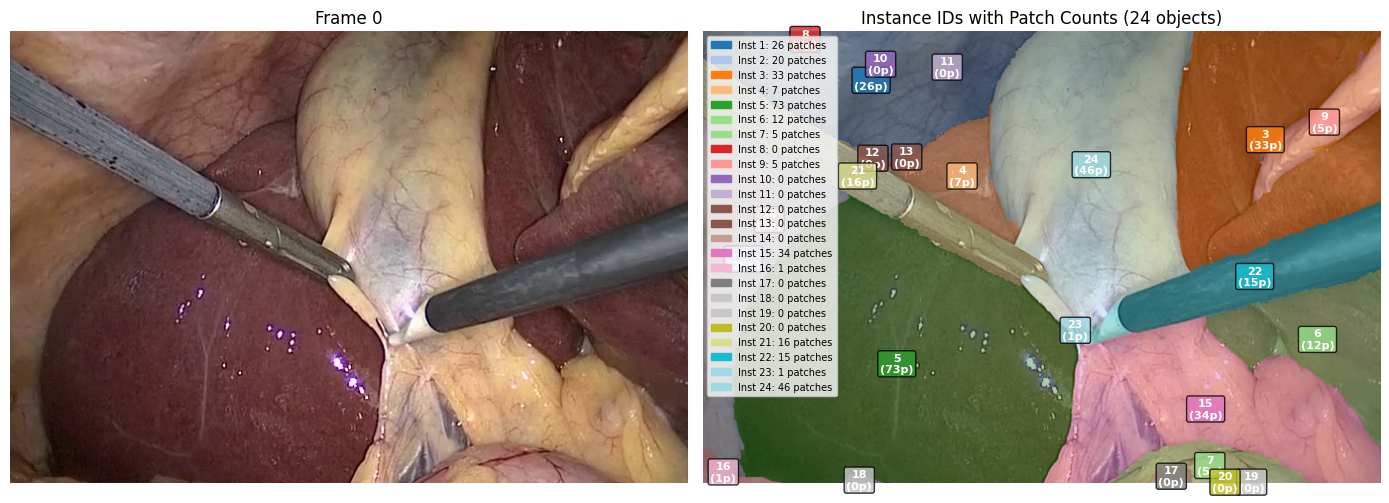

In [5]:
FRAME_IDX = 0

# File paths
frame_stem = f"{FRAME_IDX:06d}"
patch_feats_path = preprocessed_dir / "qwen3_patch_features" / f"{frame_stem}_f.npy"
patch_map_path = preprocessed_dir / "qwen3_patch_features" / f"{frame_stem}_s.npy"
instance_mask_path = preprocessed_dir / "instance_masks" / f"frame_{frame_stem}.npy"
image_path = preprocessed_dir / "images" / f"frame_{frame_stem}.png"

# Load data
patch_feats = np.load(patch_feats_path)  # (n_patches, hidden_dim * 4)
patch_map = np.load(patch_map_path)  # (1, H, W) - patch index at each pixel
instance_mask = np.load(instance_mask_path)  # (H, W) - instance ID at each pixel
image = Image.open(image_path)
image_np = np.array(image)

print(f"Patch features shape: {patch_feats.shape}")
print(f"Patch map shape: {patch_map.shape}")
print(f"Instance mask shape: {instance_mask.shape}")
print(f"Image shape: {image_np.shape}")

# Remove batch dim from patch_map
patch_map = patch_map[0]  # (H, W)

# Get unique instance IDs (0 = background)
instance_ids = np.unique(instance_mask)
print(f"\nInstance IDs: {instance_ids}")
print(f"Number of instances (including background): {len(instance_ids)}")

# Compute patch grid dimensions and factor
n_patches = patch_feats.shape[0]
H, W = patch_map.shape
# Find patch_h, patch_w such that patch_h * patch_w = n_patches
# factor = H / patch_h = W / patch_w
patch_w = int(np.sqrt(n_patches * W / H))
patch_h = n_patches // patch_w
factor = W // patch_w
print(f"\nPatch grid: {patch_h}x{patch_w}, factor: {factor}")

# Group patches by instance based on patch CENTER falling in mask
instance_to_patches = {inst_id: [] for inst_id in instance_ids}
for p in range(n_patches):
    row = p // patch_w
    col = p % patch_w
    center_y = row * factor + factor // 2
    center_x = col * factor + factor // 2
    
    # Clamp to valid range
    center_y = min(center_y, H - 1)
    center_x = min(center_x, W - 1)
    
    inst_id = instance_mask[center_y, center_x]
    instance_to_patches[inst_id].append(p)

# Convert to arrays
instance_to_patches = {k: np.array(v) for k, v in instance_to_patches.items()}
    
print(f"\nPatch grouping by instance:")
for inst_id, patches in instance_to_patches.items():
    label = "background" if inst_id == 0 else f"instance {inst_id}"
    print(f"  {label}: {len(patches)} patches (indices: {patches[:5]}{'...' if len(patches) > 5 else ''})")

def get_instance_feats(instance_id):
    return patch_feats[instance_to_patches[instance_id]]

# Visualization: overlay instance masks with feature group indices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Original image
axes[0].imshow(image_np)
axes[0].set_title(f"Frame {FRAME_IDX}")
axes[0].axis("off")

# 2. Image with instance masks and centroids labeled by feature group count
cmap = plt.cm.tab20
norm = plt.Normalize(vmin=instance_ids.min(), vmax=max(instance_ids.max(), 1))
instance_colored = cmap(norm(instance_mask))
instance_colored[instance_mask == 0] = [0, 0, 0, 0.3]  # dim background
axes[1].imshow(image_np)
axes[1].imshow(instance_colored, alpha=0.4)

# Add text labels at instance centroids
legend_patches = []
for inst_id in instance_ids:
    if inst_id == 0:
        continue  # skip background
    
    # Compute centroid
    ys, xs = np.where(instance_mask == inst_id)
    cy, cx = ys.mean(), xs.mean()
    
    n_patches = len(instance_to_patches[inst_id])
    color = cmap(norm(inst_id))[:3]
    
    axes[1].text(cx, cy, f"{inst_id}\n({n_patches}p)", 
                 ha='center', va='center', fontsize=8, fontweight='bold',
                 color='white', bbox=dict(boxstyle='round,pad=0.2', 
                                          facecolor=color, alpha=0.8))
    legend_patches.append(mpatches.Patch(color=color, label=f"Inst {inst_id}: {n_patches} patches"))

axes[1].legend(handles=legend_patches, loc='upper left', fontsize=7, framealpha=0.8)
axes[1].set_title(f"Instance IDs with Patch Counts ({len(instance_ids) - 1} objects)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9454351321309397..0.9702526111074166].


torch.Size([448, 672, 16])
tensor([[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
        ...,
        [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000]])


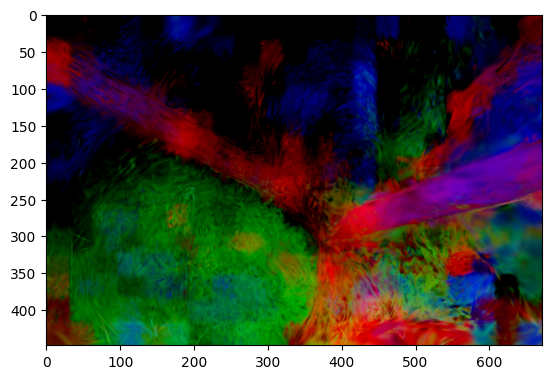

In [6]:
from sklearn.decomposition import PCA
# rendered splat features
render_path = graph_dir.parent / "video_lang" / "ours_10000" / "renders_npy" / f"{FRAME_IDX:05d}.npy"
render_feats = np.load(render_path)
render_feats = render_feats[:, :, :render_feats.shape[2] // 2]
render_feats = render_feats / torch.norm(torch.tensor(render_feats), dim=-1, keepdim=True)
print(render_feats.shape)
print(torch.norm(torch.tensor(render_feats), dim=-1))

def get_rendered_instance_feats(instance_id):
    all_latents = render_feats[instance_mask == instance_id]
    all_latents_flat = all_latents.reshape(-1, all_latents.shape[-1])
    random_latents = all_latents_flat[np.random.choice(all_latents_flat.shape[0], 64, replace=False)]
    random_latents = torch.tensor(random_latents, device=model.device).float()
    decoded_latents = autoencoder.decode(random_latents).detach()
    return decoded_latents

# viz
render_feats_flat = render_feats.reshape(-1, render_feats.shape[-1])
pca = PCA(n_components=3)
render_feats_pca = pca.fit_transform(render_feats_flat)
render_feats_pca = render_feats_pca.reshape(render_feats.shape[0], render_feats.shape[1], 3)
plt.imshow(render_feats_pca)
plt.show()

In [9]:
gallbladder = 24
grasper = 21
liver = 5
hook = 22

gallbladder_feats = torch.tensor(get_instance_feats(gallbladder), device=model.device).float()
grasper_feats = torch.tensor(get_instance_feats(grasper), device=model.device).float()
liver_feats = torch.tensor(get_instance_feats(liver), device=model.device).float()
hook_feats = torch.tensor(get_instance_feats(hook), device=model.device).float()

gallbladder_rendered = get_rendered_instance_feats(gallbladder)
grasper_rendered = get_rendered_instance_feats(grasper)
liver_rendered = get_rendered_instance_feats(liver)
hook_rendered = get_rendered_instance_feats(hook)

messages = [
    {"role": "system", "content": [{"type": "text", "text": "Your are a helpful assistant."}]},
    {
        "role": "user",
        "content": [
            {"type": "text", "text": "Image:"},
            {"type": "image", "image": None},
            {"type": "text", "text": "Which object does the image most prominently show? We're trying to classify objects that are visible during a cholecystectomy. Also mention other objects you see."},
        ],
    },
]

In [ ]:
qwen_utils.generate_with_vision_features(
    messages=messages,
    vision_features=[
        gallbladder_feats,
        # grasper_feats,
        # liver_feats,
        # hook_feats,
    ],
    model=model,
    processor=processor,
)

In [ ]:
# 2d instance patch feats random permutation
gallbladder_permuted = gallbladder_feats[torch.randperm(gallbladder_feats.shape[0])]
grasper_permuted = grasper_feats[torch.randperm(grasper_feats.shape[0])]
liver_permuted = liver_feats[torch.randperm(liver_feats.shape[0])]
hook_permuted = hook_feats[torch.randperm(hook_feats.shape[0])]

qwen_utils.generate_with_vision_features(
    messages=messages,
    vision_features=[
        # gallbladder_permuted,
        # grasper_permuted,
        # liver_permuted,
        hook_permuted,
    ],
    model=model,
    processor=processor,
)

In [ ]:
# 2d instance patch feats through autoencoder
gallbladder_ae = autoencoder.decode(autoencoder.encode(gallbladder_feats)).detach()
grasper_ae = autoencoder.decode(autoencoder.encode(grasper_feats)).detach()
liver_ae = autoencoder.decode(autoencoder.encode(liver_feats)).detach()
hook_ae = autoencoder.decode(autoencoder.encode(hook_feats)).detach()

qwen_utils.generate_with_vision_features(
    messages=messages,
    vision_features=[
        # gallbladder_ae,
        # grasper_ae,
        # liver_ae,
        hook_ae,
    ],
    model=model,
    processor=processor,
)


In [15]:
import torch.nn.functional as F

def random_rotate_vectors(vectors, angle):
    """
    Apply random rotations to each unit vector independently by exactly the specified angle.
    
    Args:
        vectors: torch.Tensor of shape (n_vecs, vecdim) - unit vectors
        angle: float - exact rotation angle in radians
    
    Returns:
        torch.Tensor of shape (n_vecs, vecdim) - rotated unit vectors
    """
    n_vecs, vecdim = vectors.shape
    device = vectors.device
    dtype = vectors.dtype
    
    # Generate random direction vectors on the unit sphere
    random_vecs = torch.randn(n_vecs, vecdim, device=device, dtype=dtype)
    random_vecs = random_vecs / random_vecs.norm(dim=1, keepdim=True)
    
    # Make random_vecs perpendicular to vectors (Gram-Schmidt)
    dot_products = (random_vecs * vectors).sum(dim=1, keepdim=True)
    perpendicular = random_vecs - dot_products * vectors
    
    # Normalize the perpendicular component
    perpendicular_norm = perpendicular.norm(dim=1, keepdim=True)
    # Handle edge case where random_vec is parallel to vector (rare but possible)
    perpendicular = torch.where(
        perpendicular_norm > 1e-6,
        perpendicular / perpendicular_norm,
        torch.randn(n_vecs, vecdim, device=device, dtype=dtype)
    )
    # Re-orthogonalize if we had to regenerate
    dot_products2 = (perpendicular * vectors).sum(dim=1, keepdim=True)
    perpendicular = perpendicular - dot_products2 * vectors
    perpendicular = perpendicular / perpendicular.norm(dim=1, keepdim=True)
    
    # Rotate by exact angle using the rotation formula:
    # v_rot = v*cos(angle) + perpendicular*sin(angle)
    cos_angle = torch.cos(torch.tensor(angle, device=device, dtype=dtype))
    sin_angle = torch.sin(torch.tensor(angle, device=device, dtype=dtype))
    
    rotated = vectors * cos_angle + perpendicular * sin_angle
    
    # Renormalize to ensure unit vectors (numerical stability)
    rotated = rotated / rotated.norm(dim=1, keepdim=True)
    
    return rotated

# latents
gallbladder_latent = autoencoder.encode(gallbladder_feats).detach()
grasper_latent = autoencoder.encode(grasper_feats).detach()
liver_latent = autoencoder.encode(liver_feats).detach()
hook_latent = autoencoder.encode(hook_feats).detach()

# latents with random rotation
angle = np.radians(21)
gallbladder_latent_noisy = random_rotate_vectors(gallbladder_latent, angle)
grasper_latent_noisy = random_rotate_vectors(grasper_latent, angle)
liver_latent_noisy = random_rotate_vectors(liver_latent, angle)
hook_latent_noisy = random_rotate_vectors(hook_latent, angle)

# reconstructions
gallbladder_ae = autoencoder.decode(gallbladder_latent).detach()
grasper_ae = autoencoder.decode(grasper_latent).detach()
liver_ae = autoencoder.decode(liver_latent).detach()
hook_ae = autoencoder.decode(hook_latent).detach()

# noisy reconstructions
gallbladder_ae_noisy = autoencoder.decode(gallbladder_latent_noisy).detach()
grasper_ae_noisy = autoencoder.decode(grasper_latent_noisy).detach()
liver_ae_noisy = autoencoder.decode(liver_latent_noisy).detach()
hook_ae_noisy = autoencoder.decode(hook_latent_noisy).detach()

# l2 errors
err_gallbladder_ae = F.l1_loss(gallbladder_feats, gallbladder_ae).item()
err_gallbladder_ae_noisy = F.l1_loss(gallbladder_feats, gallbladder_ae_noisy).item()
err_grasper_ae = F.l1_loss(grasper_feats, grasper_ae).item()
err_grasper_ae_noisy = F.l1_loss(grasper_feats, grasper_ae_noisy).item()
err_liver_ae = F.l1_loss(liver_feats, liver_ae).item()
err_liver_ae_noisy = F.l1_loss(liver_feats, liver_ae_noisy).item()
err_hook_ae = F.l1_loss(hook_feats, hook_ae).item()
err_hook_ae_noisy = F.l1_loss(hook_feats, hook_ae_noisy).item()

# reference errors
n = min(len(gallbladder_feats), len(grasper_feats))

err_gallbladder_vs_grasper = F.l1_loss(gallbladder_feats[:n], grasper_feats[:n]).item()

print("gallbladder", err_gallbladder_ae, err_gallbladder_ae_noisy, err_gallbladder_ae_noisy / err_gallbladder_ae)
print("grasper", err_grasper_ae, err_grasper_ae_noisy, err_grasper_ae_noisy / err_grasper_ae)
print("liver", err_liver_ae, err_liver_ae_noisy, err_liver_ae_noisy / err_liver_ae)
print("hook", err_hook_ae, err_hook_ae_noisy, err_hook_ae_noisy / err_hook_ae)

print()
print("gallbladder vs grasper", err_gallbladder_vs_grasper)

gallbladder 0.14702558517456055 0.30131980776786804 2.049437908443738
grasper 0.16497184336185455 0.38091596961021423 2.30897565213417
liver 0.14639204740524292 0.2925373315811157 1.9983143672505173
hook 0.15150336921215057 0.37763869762420654 2.492609237589945

gallbladder vs grasper 0.8851034045219421


In [ ]:
# respective splat clusters
gallbladder_cluster = torch.tensor(toolkit.qwen_feats["6"][FRAME_IDX], device=model.device).float()
grasper_cluster = torch.tensor(toolkit.qwen_feats["9"][FRAME_IDX], device=model.device).float()
liver_cluster = torch.tensor(toolkit.qwen_feats["1"][FRAME_IDX], device=model.device).float()
hook_cluster = torch.tensor(toolkit.qwen_feats["5"][FRAME_IDX], device=model.device).float()

qwen_utils.generate_with_vision_features(
    messages=messages,
    vision_features=[
        # gallbladder_cluster,
        # grasper_cluster,
        # liver_cluster,
        hook_cluster,
    ],
    model=model,
    processor=processor,
)


In [19]:
# 64 random rendered patch feats that fall into the instance mask
qwen_utils.generate_with_vision_features(
    messages=messages,
    vision_features=[
        # gallbladder_rendered,
        # grasper_rendered,
        # liver_rendered,
        hook_rendered,
    ],
    model=model,
    processor=processor,
)

"So, let's look at the image. The main object here is a surgical instrument, probably a laparoscopic tool, since cholecystectomy is a laparoscopic surgery. The image shows two cylindrical instruments with tips, which are typical of laparoscopic tools used in such procedures. \n\nFirst, identify the most prominent object. The two black cylindrical tools with the tips are the main things. In a cholecystectomy, common instruments include laparoscopic graspers, dissectors, or energy devices. But here, the most prominent is the surgical instrument (likely a laparoscopic tool, maybe a cautery or dissector).\n\nOther objects: The background is a bit blurred, but maybe the tissue or the surgical site, but the question is about objects visible. The main visible objects are the two surgical instruments. Since it's a close-up, the primary object is the surgical instrument (laparoscopic tool).\n\nSo, the most prominent object is a laparoscopic surgical instrument (like a laparoscopic dissector or 